In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

/home/ubuntu/.local/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# 1 Load data from "2 BrainAge"

In [2]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Basic distributions

## 2.1 Data and Descriptives

In [3]:
main_test.head()

,ID,Age,Gender,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,BADA2009,BADASEG,BADDesikan
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,-3.595835,-5.824949,1.980465
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,4.049976,-2.298881,-4.984119
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,1.382366,-3.967790,4.538872
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,-4.910601,-11.407986,18.847508
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,-5.202788,-4.301580,15.729320


Remove outliers on SR PA

In [4]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 563
5422


Remove people with Gender other than Male or Female

In [5]:
before = main_test.shape[0]
main_test = main_test[(main_test["Gender"] == "Female") | (main_test["Gender"] == "Male")]
after = main_test.shape[0]
print("Gender not Male or Female:", before-after)
print(after)

Gender not Male or Female: 0
5422


### 2.1.1 Test set

In [6]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("LPA")
mean = female["LPA"].mean()
print("Female", mean)
std = female["LPA"].std()
print("Female",std)
mean = male["LPA"].mean()
print("Male",mean)
std = male["LPA"].std()
print("Male",std)

print("MPA")
mean = female["MPA"].mean()
print("Female", mean)
std = female["MPA"].std()
print("Female",std)
mean = male["MPA"].mean()
print("Male",mean)
std = male["MPA"].std()
print("Male",std)

print("VPA")
mean = female["VPA"].mean()
print("Female", mean)
std = female["VPA"].std()
print("Female",std)
mean = male["VPA"].mean()
print("Male",mean)
std = male["VPA"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("IS")
print("Female")
print(female["IS"].value_counts())
print("Male")
print(male["IS"].value_counts())

Number of females: 2898
NUmber of males: 2524
Age
Female 63.49482401656315
Female 7.556813291182583
Male 65.49207606973059
Male 7.824543474679913
LPA
Female 2056.1930434782607
Female 406.8644273491336
Male 1885.7437103011096
Male 405.84204331256376
MPA
Female 498.95904596273294
Female 226.04598507597225
Male 467.3088513470682
Male 219.2158898210811
VPA
Female 31.376486956521767
Female 41.49015419937569
Male 36.690498256735374
Male 47.658656646516
SRLPA
Female 788.5644927536232
Female 716.9490442462906
Male 753.3099841521395
Male 709.4481511450006
SRMPA
Female 658.1545893719807
Female 770.9382013505868
Male 607.4136291600634
Male 758.2566221943127
SRVPA
Female 476.40855762594896
Female 630.0607737527736
Male 553.9492868462758
Male 692.3469152768914
DBP
Female 79.28433402346445
Female 10.25709733932206
Male 83.24167987321711
Male 10.189301689365152
SBP
Female 133.13077984817116
Female 19.121772759199146
Male 140.57369255150556
Male 17.608384631991797
BMI
Female 25.811531090407172
Female 

### 2.1.2 Train set

In [7]:
# get mean and std for all variables for males and females seperately for the train set
female = main_train[main_train["Gender"] == "Female"]
male = main_train[main_train["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("IS")
print("Female")
print(female["IS"].value_counts())
print("Male")
print(male["IS"].value_counts())

Number of females: 11117
NUmber of males: 10325
Age
Female 63.836196815687686
Female 7.503871583194821
Male 65.00474576271186
Male 7.7586035249436
SRLPA
Female 984.1847981520185
Female 1033.3820726927277
Male 928.3805084745763
Male 1007.0754562865242
SRMPA
Female 837.8537014629853
Female 1113.6645965459636
Male 817.7301342725071
Male 1131.3713559199134
SRVPA
Female 574.130018699813
Female 920.1960026012333
Male 741.4853620955316
Male 1148.5582239428738
BMI
Female 26.138465982351878
Female 4.582669799430477
Male 27.191944284882588
Male 3.7562568482626655
DBP
Female 79.32254626489681
Female 10.228206380591313
Male 83.40178664173678
Male 10.089943983473264
SBP
Female 132.82763298130027
Female 19.06073106946566
Male 140.33489145112705
Male 17.42547072290952
HG
Female 25.921382796281254
Female 6.415775125843123
Male 42.48262473306154
Male 8.766859109259675
HR
Female 69.22216839453542
Female 10.393253848960265
Male 66.84958969564765
Male 11.43598977944362
IS
Female
11025    6408
11027    305

## 2.3 Age and BrainAge

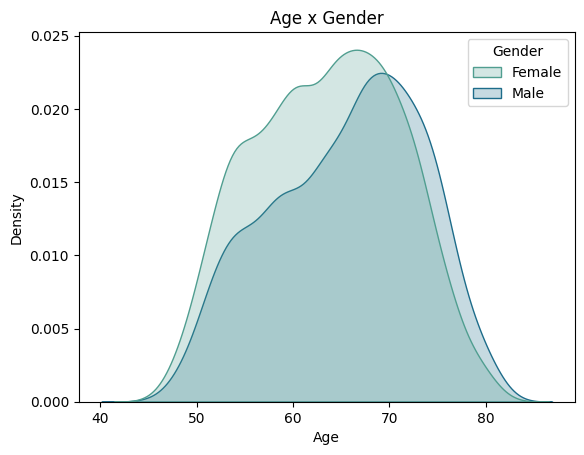

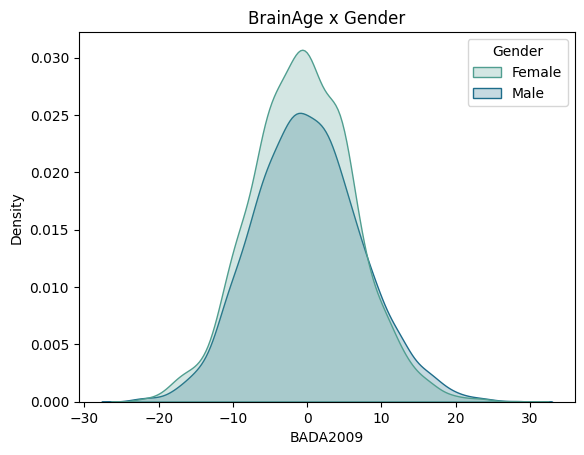

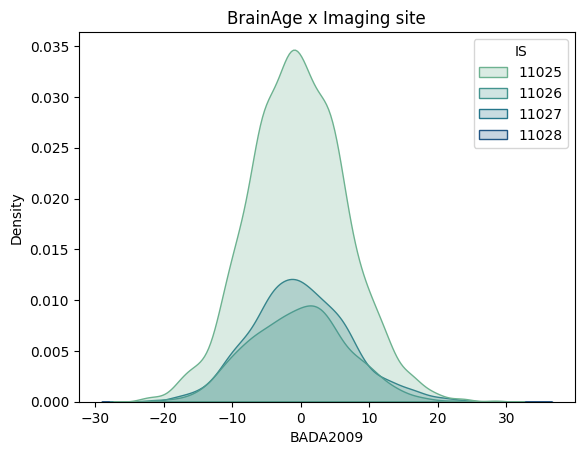

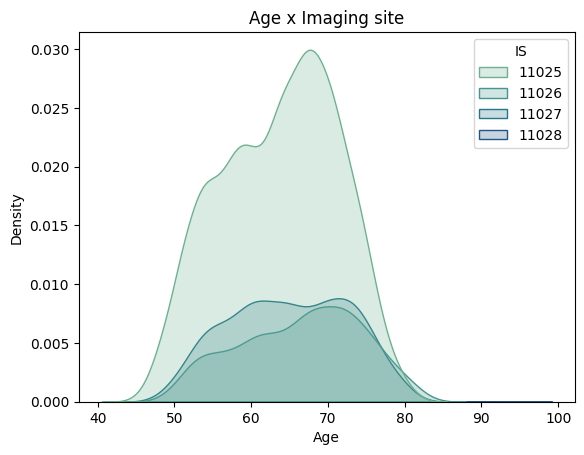

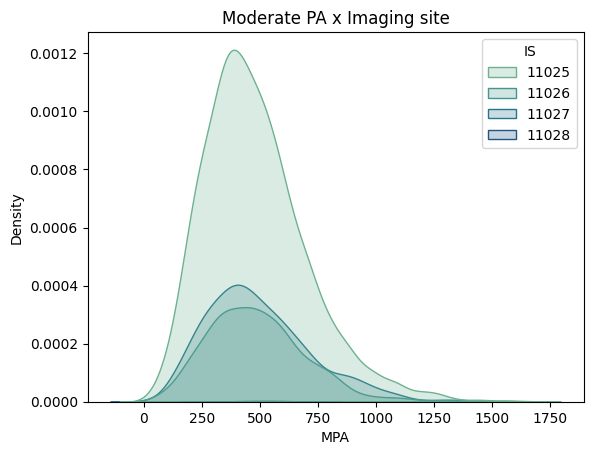

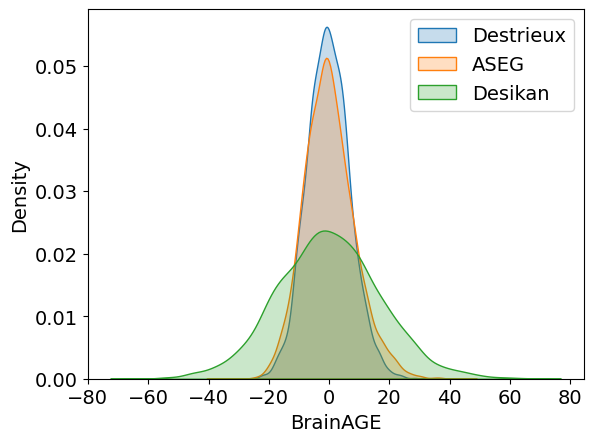

In [8]:
# plot Age by Gender
plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
plt.title("Age x Gender")
plt.show()

# plot BrainAGE by Gender
plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'Gender', fill=True, palette = "crest")
plt.title("BrainAge x Gender")
plt.show()

# plot BrainAGE by Imaging Site
plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'IS', fill=True, palette = "crest")
plt.title("BrainAge x Imaging site")
plt.show()

# plot Age by Imaging Site
plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
plt.title("Age x Imaging site")
plt.show()

# plot Moderate PA by Imaging Site
plt.figure()
sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
plt.title("Moderate PA x Imaging site")
plt.show()

# plot BrainAGE Segmentations
plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', fill=True, label="Destrieux")
sns.kdeplot(data = main_test, x= 'BADASEG', fill=True, label="ASEG")
sns.kdeplot(data = main_test, x= 'BADDesikan', fill=True, label="Desikan")
plt.xlabel("BrainAGE", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

## 2.4 Physical activity

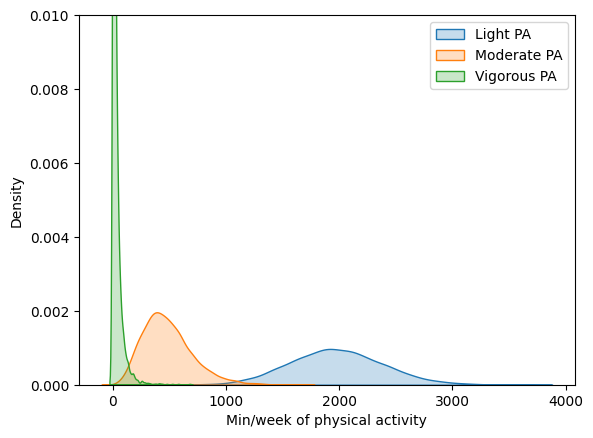

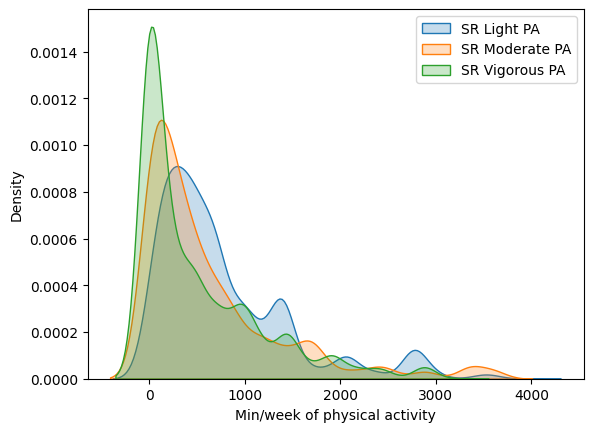

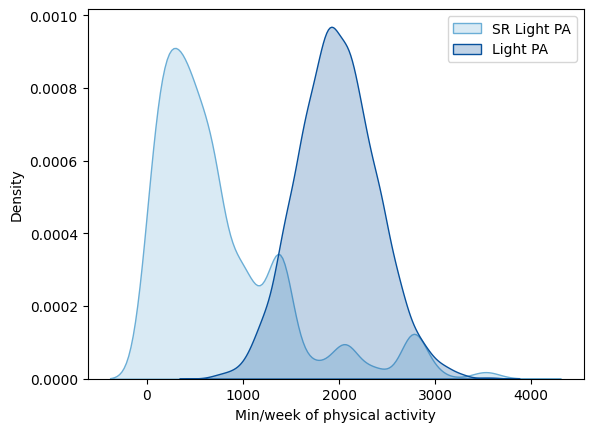

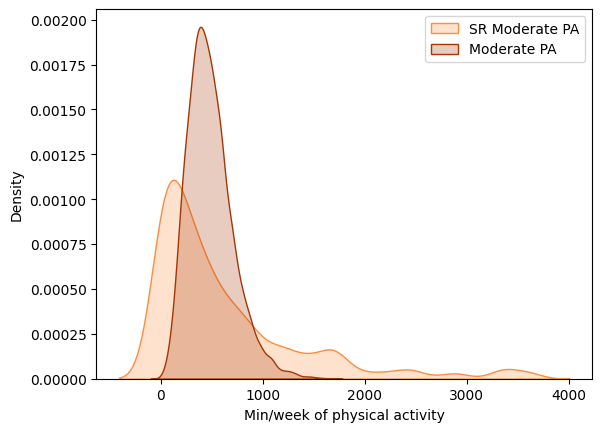

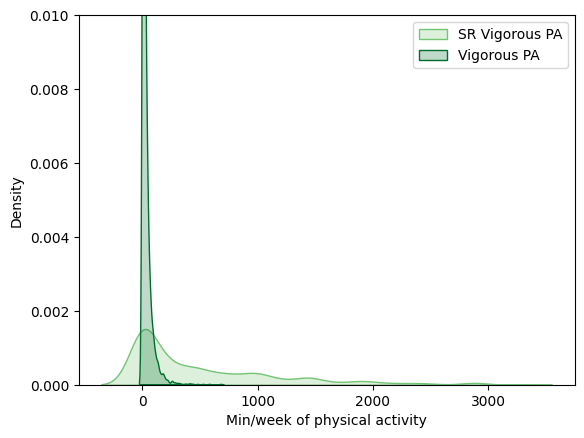

In [9]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately
plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.xticks(range(0,5000,1000))
plt.ylim(0,0.01)
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
plt.ylim(0,0.01)
plt.xticks(range(0,3500,1000))
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.show()

## 2.5 Fitness

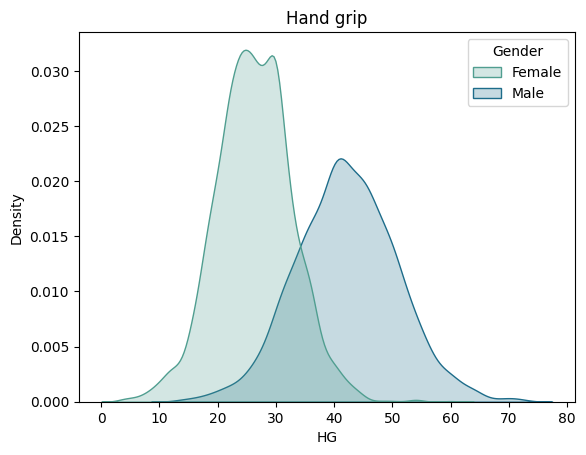

In [10]:
# plot dominant hand grip strength
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip")
plt.show()

## 2.6 Health

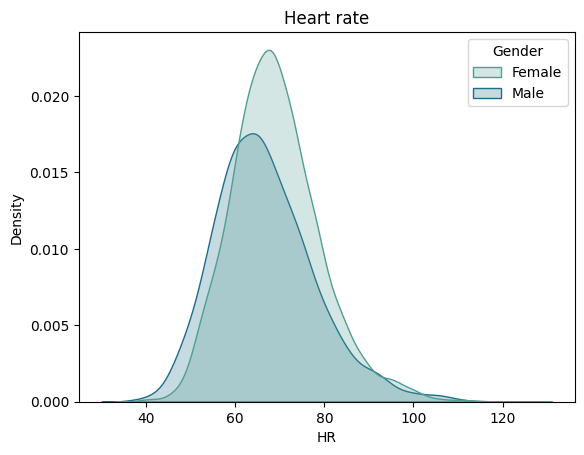

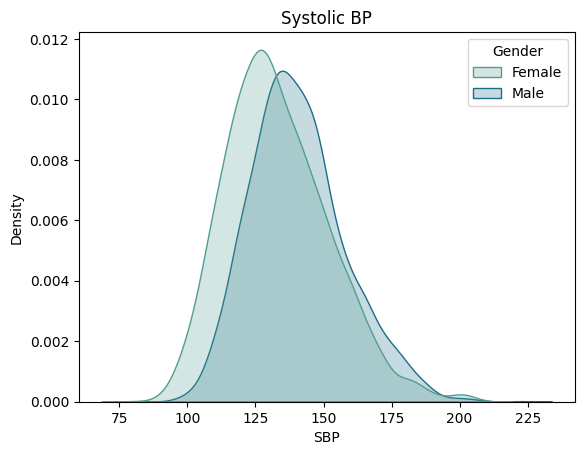

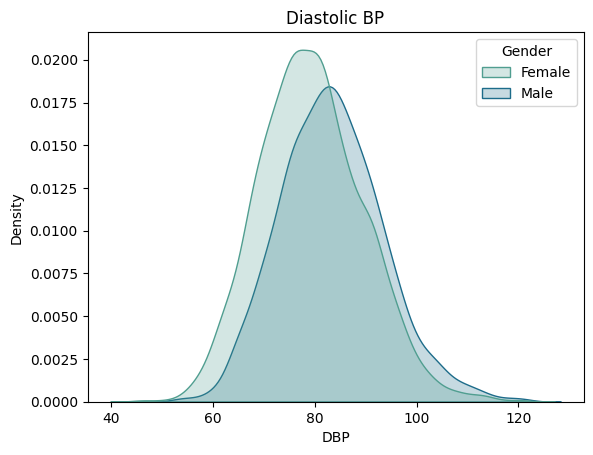

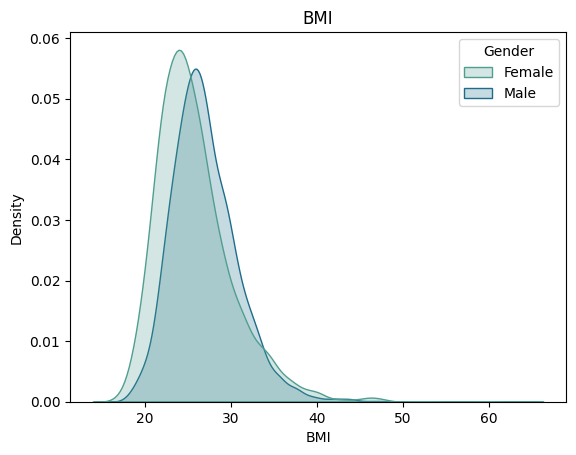

In [11]:
# plot Heart rate
plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

# plot systolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

# plot diastolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Diastolic BP")
plt.show()

# plot BMI
plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

# 3 Recode variables

In [12]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 1, '11026': 2,'11027': 3, '11028': 4})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test = main_test.rename(columns={"BADA2009": "BA"})

# delete unused variables
del main_test["ID"]
del main_test["BADDesikan"]
del main_test["BADASEG"]
del main_test["MVPA"]
del main_test["TPA"]

# standardize all variables except Gender, Age, BrainAGE, Imaging site
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI"]], nan_policy='omit')

## 3.1 Compute Total and Moderate-Vigorous PA (not used)

In [13]:
# main_test["TPA"] = main_test["LPA"] + main_test["MPA"] + main_test["VPA"]
# main_test["SRTPA"] = main_test["SRLPA"] + main_test["SRMPA"] + main_test["SRVPA"]
# main_test["MVPA"] = main_test["MPA"] + main_test["VPA"]
# main_test["SRMVPA"] = main_test["SRMPA"] + main_test["SRVPA"]

## 3.2 Computed Combined Risk score

In [14]:
# combined risk score for self-report and accelerometer -> summing z-scores of best PA and health and fitness variables
# multiply fitness and PA by -1
main_test["CR"] = main_test["MPA"]*-1 + main_test["HG"]*-1 + main_test["DBP"] + main_test["SBP"] + main_test["HR"] + main_test["BMI"]
main_test["SRCR"] = main_test["SRMPA"]*-1 + main_test["HG"]*-1 + main_test["DBP"] + main_test["SBP"] + main_test["HR"] + main_test["BMI"]

## 3.3 Copy BrainAGE to end of dataframe

In [15]:
brainage = main_test["BA"]
del main_test["BA"]
main_test["BA"] = brainage

## 3.4 Remove effect of Age on all predictor variables (regression -> residuals)

In [16]:
model = ols("LPA ~ Age", data = main_test).fit()
main_test["LPA"] = model.resid

model = ols("MPA ~ Age", data = main_test).fit()
main_test["MPA"] = model.resid

model = ols("VPA ~ Age", data = main_test).fit()
main_test["VPA"] = model.resid

model = ols("SRLPA ~ Age", data = main_test).fit()
main_test["SRLPA"] = model.resid

model = ols("SRMPA ~ Age", data = main_test).fit()
main_test["SRMPA"] = model.resid

model = ols("SRVPA ~ Age", data = main_test).fit()
main_test["SRVPA"] = model.resid

model = ols("CR ~ Age", data = main_test).fit()
main_test["CR"] = model.resid

model = ols("SRCR ~ Age", data = main_test).fit()
main_test["SRCR"] = model.resid

model = ols("HR ~ Age", data = main_test).fit()
main_test["HR"] = model.resid

model = ols("DBP ~ Age", data = main_test).fit()
main_test["DBP"] = model.resid

model = ols("SBP ~ Age", data = main_test).fit()
main_test["SBP"] = model.resid

model = ols("BMI ~ Age", data = main_test).fit()
main_test["BMI"] = model.resid

model = ols("HG ~ Age", data = main_test).fit()
main_test["HG"] = model.resid

##

# model = ols("TPA ~ Age", data = main_test).fit()
# main_test["TPA"] = model.resid

# model = ols("MVPA ~ Age", data = main_test).fit()
# main_test["MVPA"] = model.resid

# model = ols("SRTPA ~ Age", data = main_test).fit()
# main_test["SRTPA"] = model.resid

# model = ols("SRMVPA ~ Age", data = main_test).fit()
# main_test["SRMVPA"] = model.resid

## 3.5 Descriptives for combined risk score (only test)

In [17]:
female = main_test[main_test["Gender"] == 0]
male = main_test[main_test["Gender"]== 1]

print("CR")
mean = female["CR"].mean()
print("Female", mean)
std = female["CR"].std()
print("Female",std)
mean = male["CR"].mean()
print("Male",mean)
std = male["CR"].std()
print("Male",std)

print("SRCR")
mean = female["SRCR"].mean()
print("Female", mean)
std = female["SRCR"].std()
print("Female",std)
mean = male["SRCR"].mean()
print("Male",mean)
std = male["SRCR"].std()
print("Male",std)

CR
Female 0.311477383360164
Female 3.1128396534316147
Male -0.3576313220989637
Male 2.923941964203461
SRCR
Female 0.3051309507652921
Female 3.00314483004661
Male -0.35034449101340315
Male 2.8881463789459927


# 4 Simple correlation heatmap

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'Gender'),
  Text(0, 2.5, 'IS'),
  Text(0, 3.5, 'VPA'),
  Text(0, 4.5, 'MPA'),
  Text(0, 5.5, 'LPA'),
  Text(0, 6.5, 'SRLPA'),
  Text(0, 7.5, 'SRMPA'),
  Text(0, 8.5, 'SRVPA'),
  Text(0, 9.5, 'HG'),
  Text(0, 10.5, 'HR'),
  Text(0, 11.5, 'BMI'),
  Text(0, 12.5, 'DBP'),
  Text(0, 13.5, 'SBP'),
  Text(0, 14.5, 'CR'),
  Text(0, 15.5, 'SRCR'),
  Text(0, 16.5, 'BA')])

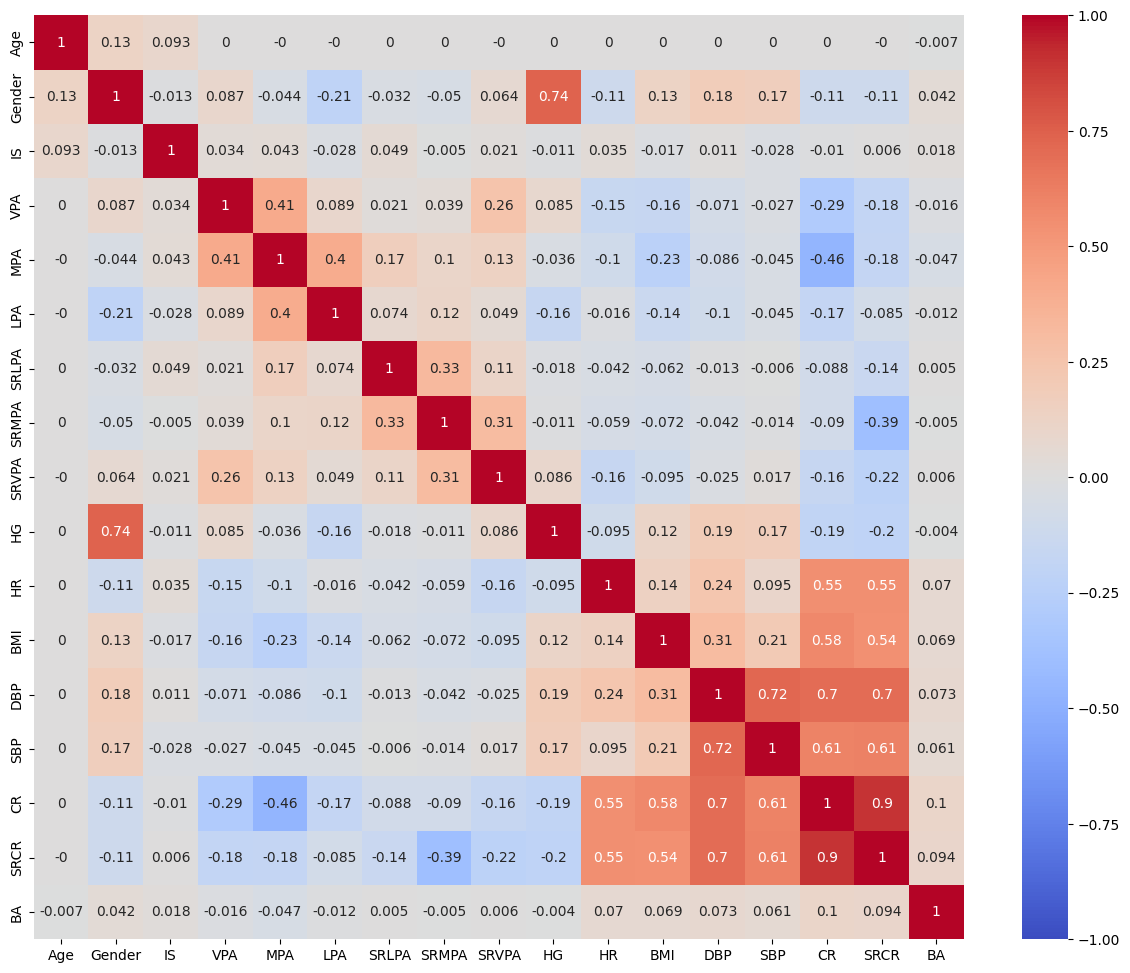

In [18]:
corr = main_test.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

## 4.1 Female

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'IS'),
  Text(0, 2.5, 'VPA'),
  Text(0, 3.5, 'MPA'),
  Text(0, 4.5, 'LPA'),
  Text(0, 5.5, 'SRLPA'),
  Text(0, 6.5, 'SRMPA'),
  Text(0, 7.5, 'SRVPA'),
  Text(0, 8.5, 'HG'),
  Text(0, 9.5, 'HR'),
  Text(0, 10.5, 'BMI'),
  Text(0, 11.5, 'DBP'),
  Text(0, 12.5, 'SBP'),
  Text(0, 13.5, 'CR'),
  Text(0, 14.5, 'SRCR'),
  Text(0, 15.5, 'BA')])

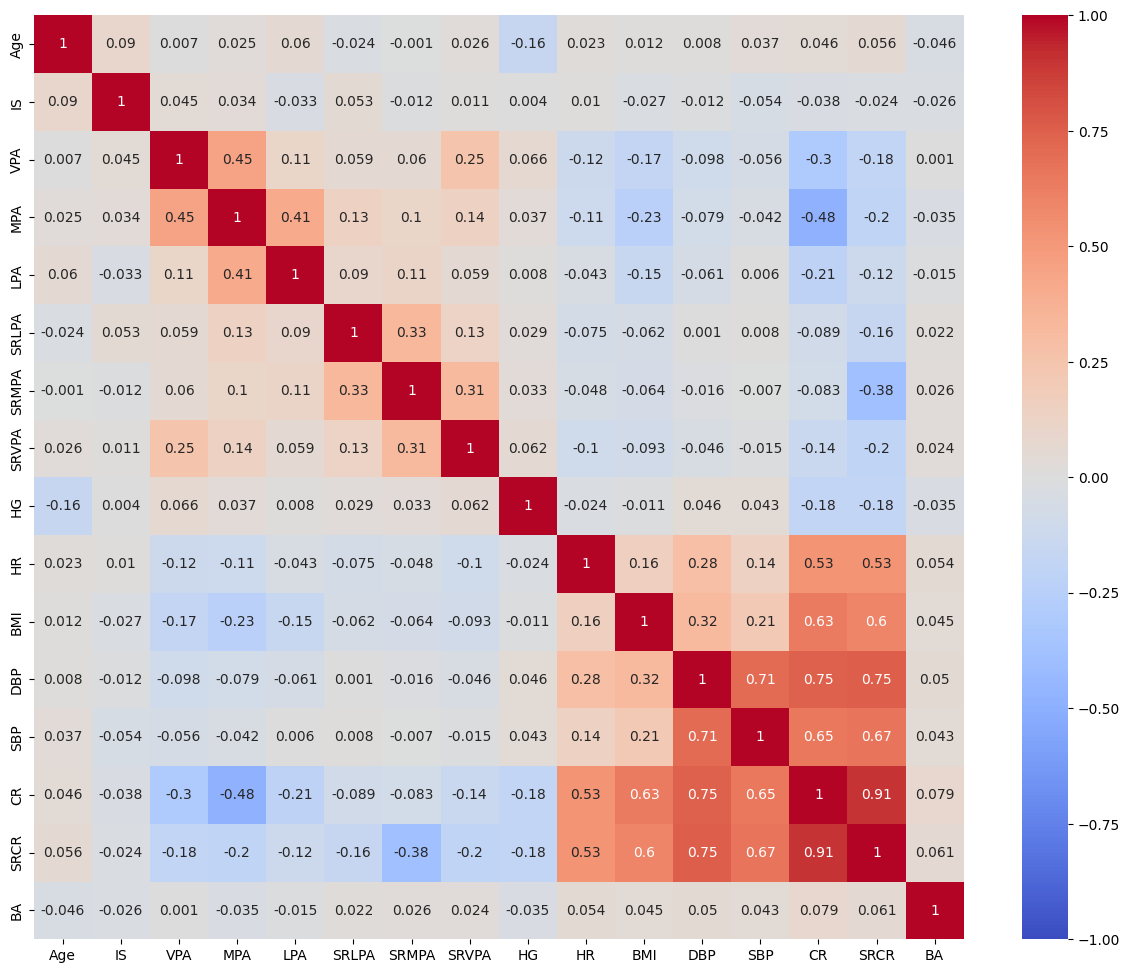

In [19]:
female = main_test[main_test["Gender"] == 0]
del female["Gender"]
corr = female.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

## 4.2 Male

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'IS'),
  Text(0, 2.5, 'VPA'),
  Text(0, 3.5, 'MPA'),
  Text(0, 4.5, 'LPA'),
  Text(0, 5.5, 'SRLPA'),
  Text(0, 6.5, 'SRMPA'),
  Text(0, 7.5, 'SRVPA'),
  Text(0, 8.5, 'HG'),
  Text(0, 9.5, 'HR'),
  Text(0, 10.5, 'BMI'),
  Text(0, 11.5, 'DBP'),
  Text(0, 12.5, 'SBP'),
  Text(0, 13.5, 'CR'),
  Text(0, 14.5, 'SRCR'),
  Text(0, 15.5, 'BA')])

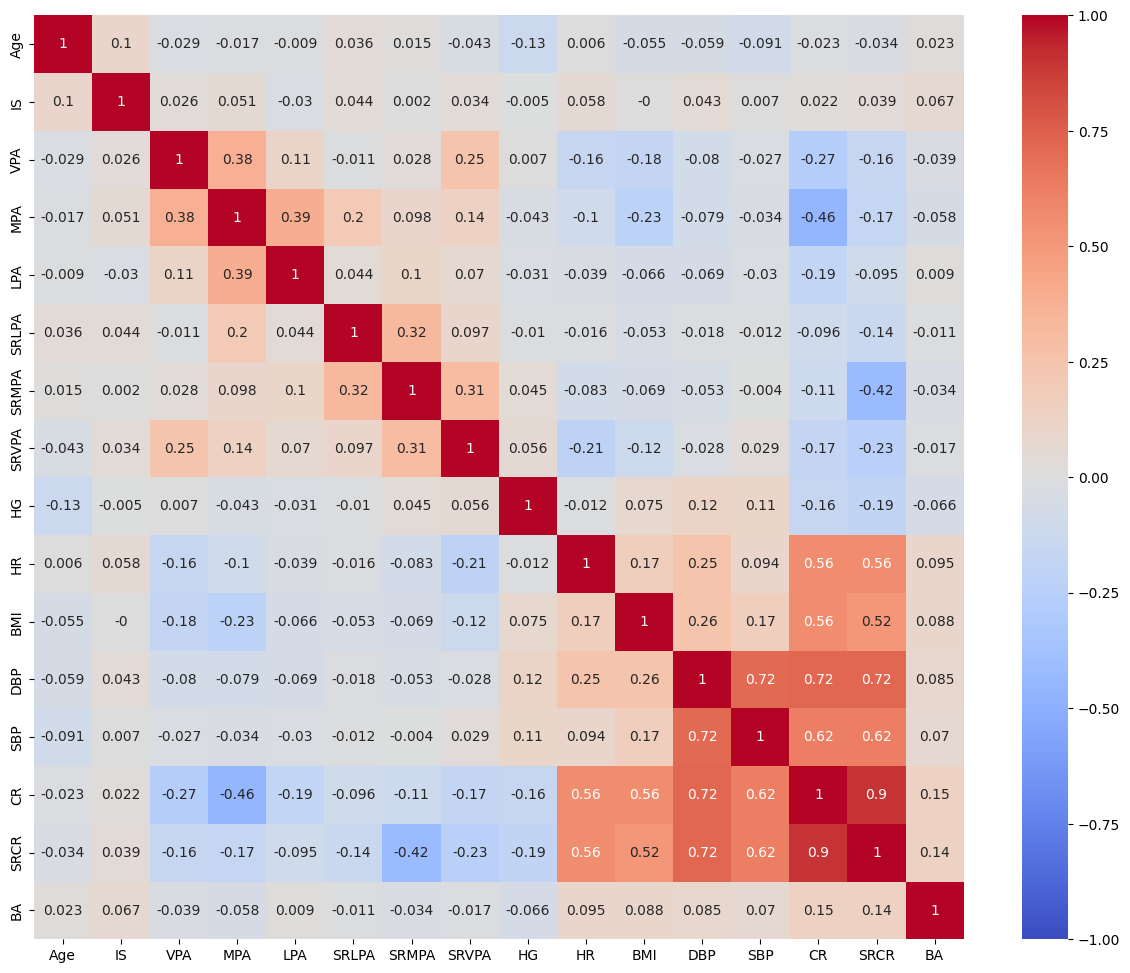

In [20]:
male = main_test[main_test["Gender"] == 1]
del male["Gender"]
corr = male.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

# 6 Models OLS

## 6.1 Single Predictor Models

### 6.1.1 Accelerometer PA

In [21]:
lpa = ols('BA ~ LPA + Gender + IS + Gender:LPA', missing='drop', data = main_test).fit()
print(lpa.summary())

#calculate effect size
results = lpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.008
Date:                Mon, 13 Feb 2023   Prob (F-statistic):             0.0172
Time:                        17:58:00   Log-Likelihood:                -18308.
No. Observations:                5422   AIC:                         3.663e+04
Df Residuals:                    5417   BIC:                         3.666e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8518      0.233     -3.662      0.0

In [22]:
mpa = ols('BA ~ MPA + Gender + IS + Gender:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.976
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           8.53e-05
Time:                        17:58:01   Log-Likelihood:                -18302.
No. Observations:                5422   AIC:                         3.661e+04
Df Residuals:                    5417   BIC:                         3.665e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8918      0.230     -3.871      0.0

In [23]:
vpa = ols('BA ~ VPA + Gender +  IS + Gender:VPA', missing='drop', data = main_test).fit()
print(vpa.summary())

#calculate effect size
results = vpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.837
Date:                Mon, 13 Feb 2023   Prob (F-statistic):            0.00407
Time:                        17:58:01   Log-Likelihood:                -18306.
No. Observations:                5422   AIC:                         3.662e+04
Df Residuals:                    5417   BIC:                         3.666e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8799      0.231     -3.806      0.0

### 6.1.2 Self-report PA

In [24]:
srlpa = ols('BA ~ SRLPA + Gender + IS + Gender:SRLPA', missing='drop', data = main_test).fit()
print(srlpa.summary())

#calculate effect size
results = srlpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.189
Date:                Mon, 13 Feb 2023   Prob (F-statistic):             0.0126
Time:                        17:58:02   Log-Likelihood:                -18308.
No. Observations:                5422   AIC:                         3.663e+04
Df Residuals:                    5417   BIC:                         3.666e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.8725      0.231     -3.783   

In [25]:
srmpa = ols('BA ~ SRMPA + Gender + IS + Gender:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.041
Date:                Mon, 13 Feb 2023   Prob (F-statistic):            0.00283
Time:                        17:58:03   Log-Likelihood:                -18306.
No. Observations:                5422   AIC:                         3.662e+04
Df Residuals:                    5417   BIC:                         3.665e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.8840      0.231     -3.834   

In [26]:
srvpa = ols('BA ~ SRVPA + Gender + IS + Gender:SRVPA', missing='drop', data = main_test).fit()
print(srvpa.summary())

#calculate effect size
results = srvpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.391
Date:                Mon, 13 Feb 2023   Prob (F-statistic):            0.00888
Time:                        17:58:03   Log-Likelihood:                -18307.
No. Observations:                5422   AIC:                         3.662e+04
Df Residuals:                    5417   BIC:                         3.666e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.8650      0.231     -3.748   

### 6.1.3 Combined risk scores (Acc)

In [27]:
cr = ols('BA ~ CR + Gender + IS + Gender:CR', missing='drop', data = main_test).fit()
print(cr.summary())

#calculate effect size
results = cr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     21.96
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           5.32e-18
Time:                        17:58:03   Log-Likelihood:                -18270.
No. Observations:                5422   AIC:                         3.655e+04
Df Residuals:                    5417   BIC:                         3.658e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9279      0.230     -4.039      0.0

#### 6.1.3.1 Males

In [28]:
male = main_test[main_test["Gender"] == 1]

crm = ols('BA ~ CR + IS', missing='drop', data = male).fit()
print(crm.summary())

#calculate effect size
results = crm
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     33.66
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           3.76e-15
Time:                        17:58:04   Log-Likelihood:                -8557.3
No. Observations:                2524   AIC:                         1.712e+04
Df Residuals:                    2521   BIC:                         1.714e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7972      0.313     -2.544      0.0

#### 6.1.3.2 Females

In [29]:
female = main_test[main_test["Gender"] == 0]

crf = ols('BA ~ CR + IS', missing='drop', data = female).fit()
print(crf.summary())

#calculate effect size
results = crf
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.778
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           5.86e-05
Time:                        17:58:05   Log-Likelihood:                -9705.4
No. Observations:                2898   AIC:                         1.942e+04
Df Residuals:                    2895   BIC:                         1.943e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3554      0.283     -1.255      0.2

### 6.1.4 Combined risk score (SR)

In [30]:
srcr = ols('BA ~ SRCR + Gender + IS + Gender:SRCR', missing='drop', data = main_test).fit()
print(srcr.summary())

#calculate effect size
results = srcr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     19.02
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           1.52e-15
Time:                        17:58:05   Log-Likelihood:                -18276.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5417   BIC:                         3.660e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.8905      0.230     -3.874      

### 6.1.5 Health & Fitness

In [31]:
hg = ols('BA ~ HG + Gender + IS + Gender:HG', missing='drop', data = main_test).fit()
print(hg.summary())

#calculate effect size
results = hg
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     6.572
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           2.85e-05
Time:                        17:58:05   Log-Likelihood:                -18301.
No. Observations:                5422   AIC:                         3.661e+04
Df Residuals:                    5417   BIC:                         3.664e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1611      0.279     -4.163      0.0

In [32]:
hr = ols('BA ~ HR + Gender + IS + Gender:HR', missing='drop', data = main_test).fit()
print(hr.summary())

#calculate effect size
results = hr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     10.81
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           9.89e-09
Time:                        17:58:06   Log-Likelihood:                -18292.
No. Observations:                5422   AIC:                         3.659e+04
Df Residuals:                    5417   BIC:                         3.663e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8746      0.230     -3.796      0.0

In [33]:
bmi = ols('BA ~ BMI + Gender + IS + Gender:BMI', missing='drop', data = main_test).fit()
print(bmi.summary())

#calculate effect size
results = bmi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.492
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           1.21e-07
Time:                        17:58:06   Log-Likelihood:                -18295.
No. Observations:                5422   AIC:                         3.660e+04
Df Residuals:                    5417   BIC:                         3.663e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8457      0.230     -3.672      0.0

In [34]:
dbp = ols('BA ~ DBP + Gender + IS + Gender:DBP', missing='drop', data = main_test).fit()
print(dbp.summary())

#calculate effect size
results = dbp
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.289
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           1.77e-07
Time:                        17:58:06   Log-Likelihood:                -18295.
No. Observations:                5422   AIC:                         3.660e+04
Df Residuals:                    5417   BIC:                         3.663e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7936      0.231     -3.435      0.0

In [35]:
sbp = ols('BA ~ SBP + Gender + IS + Gender:SBP', missing='drop', data = main_test).fit()
print(sbp.summary())

#calculate effect size
results = sbp
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     7.378
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           6.38e-06
Time:                        17:58:07   Log-Likelihood:                -18299.
No. Observations:                5422   AIC:                         3.661e+04
Df Residuals:                    5417   BIC:                         3.664e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8400      0.231     -3.644      0.0

## 6.2 Multiple Predictor & Comparison Models

### 6.2.1 Covariates

In [36]:
cov_model = ols('BA ~ Gender + Age + IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.104
Date:                Mon, 13 Feb 2023   Prob (F-statistic):            0.00642
Time:                        17:58:07   Log-Likelihood:                -18308.
No. Observations:                5422   AIC:                         3.662e+04
Df Residuals:                    5418   BIC:                         3.665e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0486      0.814     -0.060      0.9

### 6.2.2 Accelerometer + Self-report PA

In [37]:
sr_pa_model = ols('BA ~ SRMPA + MPA + Gender + IS', missing='drop', data = main_test).fit()
print(sr_pa_model.summary())

#calculate effect size
results = sr_pa_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     5.721
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           0.000136
Time:                        17:58:07   Log-Likelihood:                -18303.
No. Observations:                5422   AIC:                         3.662e+04
Df Residuals:                    5417   BIC:                         3.665e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8875      0.230     -3.851      0.0

### 6.2.3 PA + Fitness

In [38]:
pa_fitness = ols('BA ~ HG + MPA + IS + Gender', missing='drop', data = main_test).fit()
print(pa_fitness.summary())

#calculate effect size
results = pa_fitness
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.422
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           1.38e-07
Time:                        17:58:07   Log-Likelihood:                -18295.
No. Observations:                5422   AIC:                         3.660e+04
Df Residuals:                    5417   BIC:                         3.663e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2603      0.250     -5.046      0.0

### 6.2.4 Health

In [39]:
health = ols('BA ~ SBP + HR + DBP + BMI + Gender + IS', missing='drop', data = main_test).fit()
print(health.summary())

#calculate effect size
results = health
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     10.98
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           3.40e-12
Time:                        17:58:08   Log-Likelihood:                -18281.
No. Observations:                5422   AIC:                         3.658e+04
Df Residuals:                    5415   BIC:                         3.662e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8147      0.231     -3.534      0.0

### 6.2.5 Health & Fitness

In [40]:
he_fi = ols('BA ~ HG + SBP + HR + DBP + BMI + Gender + IS', missing='drop', data = main_test).fit()
print(he_fi.summary())

#calculate effect size
results = he_fi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     11.91
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           3.79e-15
Time:                        17:58:08   Log-Likelihood:                -18273.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5414   BIC:                         3.661e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2111      0.249     -4.860      0.0

### 6.2.6 PA & Health

In [41]:
pa_he = ols('BA ~ MPA + SBP + HR + DBP + BMI + Gender + IS', missing='drop', data = main_test).fit()
print(pa_he.summary())

#calculate effect size
results = pa_he
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     10.04
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           1.59e-12
Time:                        17:58:08   Log-Likelihood:                -18279.
No. Observations:                5422   AIC:                         3.657e+04
Df Residuals:                    5414   BIC:                         3.663e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8268      0.231     -3.586      0.0

### 6.2.7 PA + Health + Fitness

In [42]:
pa_he_fi = ols('BA ~ MPA + HG + SBP + HR + DBP + BMI + Gender + IS', missing='drop', data = main_test).fit()
print(pa_he_fi.summary())

#calculate effect size
results = pa_he_fi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     10.97
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           1.80e-15
Time:                        17:58:09   Log-Likelihood:                -18270.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5413   BIC:                         3.662e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2233      0.249     -4.909      0.0

### 6.2.8 SR PA + Health + Fitness

In [43]:
sr_pa_he_fi = ols('BA ~ SRMPA + HG + SBP + HR + DBP + BMI + Gender + IS', missing='drop', data = main_test).fit()
print(sr_pa_he_fi.summary())

#calculate effect size
results = sr_pa_he_fi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     10.45
Date:                Mon, 13 Feb 2023   Prob (F-statistic):           1.19e-14
Time:                        17:58:09   Log-Likelihood:                -18272.
No. Observations:                5422   AIC:                         3.656e+04
Df Residuals:                    5413   BIC:                         3.662e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2160      0.249     -4.876      0.0

# 7 Model comparisons

## 7.1 Cov x PA

In [44]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  271983.194876      0.0         NaN       NaN       NaN
1    5417.0  271403.595138      1.0  579.599738  11.56835  0.000676


In [45]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  271983.194876      0.0         NaN       NaN       NaN
1    5417.0  271790.230731      1.0  192.964145  3.845932  0.049918


## 7.2 Cov x PA x SR

In [46]:
model_comparison = anova_lm(srmpa, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff    F  Pr(>F)
0    5417.0  271790.230731      0.0         NaN  NaN     NaN
1    5417.0  271403.595138     -0.0  386.635592 -inf     NaN


## 7.3 Health x Fitness x PA

In [47]:
model_comparison = anova_lm(pa_fitness, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff    F  Pr(>F)
0    5417.0  270717.751440      0.0         NaN  NaN     NaN
1    5417.0  271403.595138     -0.0 -685.843698  inf     NaN


In [48]:
model_comparison = anova_lm(mpa, pa_he)
print(model_comparison)

   df_resid            ssr  df_diff      ss_diff          F        Pr(>F)
0    5417.0  271403.595138      0.0          NaN        NaN           NaN
1    5414.0  269109.093522      3.0  2294.501616  15.387108  5.755726e-10


In [49]:
model_comparison = anova_lm(mpa, pa_he_fi)
print(model_comparison)

   df_resid            ssr  df_diff      ss_diff          F        Pr(>F)
0    5417.0  271403.595138      0.0          NaN        NaN           NaN
1    5413.0  268252.592867      4.0  3151.002272  15.895816  6.086646e-13


## 7.4 CR vs. Individual

In [50]:
model_comparison = anova_lm(cr, pa_he_fi)
print(model_comparison)

   df_resid            ssr  df_diff   ss_diff         F  Pr(>F)
0    5417.0  268251.783824      0.0       NaN       NaN     NaN
1    5413.0  268252.592867      4.0 -0.809042 -0.004081     1.0


In [51]:
model_comparison = anova_lm(srcr, sr_pa_he_fi)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5417.0  268826.054758      0.0        NaN       NaN       NaN
1    5413.0  268453.624317      4.0  372.43044  1.877388  0.111457


## 7.5 Genders

In [52]:
model_comparison = anova_lm(crf, crm)
print(model_comparison)

   df_resid            ssr  df_diff      ss_diff        F  Pr(>F)
0    2895.0  137568.184816      0.0          NaN      NaN     NaN
1    2521.0  130157.087251    374.0  7411.097565  0.38381     1.0


# 8 Mediation analysis

## 8.1 PA x Health / Fitness

### 8.1.1 BMI

In [53]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.066935       -0.102704       -0.034287    0.000
ACME (treated)           -0.066935       -0.102704       -0.034287    0.000
ADE (control)            -0.011738       -0.207829        0.179462    0.942
ADE (treated)            -0.011738       -0.207829        0.179462    0.942
Total effect             -0.078673       -0.271456        0.111835    0.410
Prop. mediated (control)  0.519386       -9.901252        8.086229    0.410
Prop. mediated (treated)  0.519386       -9.901252        8.086229    0.410
ACME (average)           -0.066935       -0.102704       -0.034287    0.000
ADE (average)            -0.011738       -0.207829        0.179462    0.942
Prop. mediated (average)  0.519386       -9.901252        8.086229    0.410


In [54]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.103680       -0.156460       -0.056750    0.000
ACME (treated)           -0.103680       -0.156460       -0.056750    0.000
ADE (control)            -0.235588       -0.428052       -0.045435    0.022
ADE (treated)            -0.235588       -0.428052       -0.045435    0.022
Total effect             -0.339268       -0.530081       -0.142785    0.000
Prop. mediated (control)  0.301711        0.151235        0.731107    0.000
Prop. mediated (treated)  0.301711        0.151235        0.731107    0.000
ACME (average)           -0.103680       -0.156460       -0.056750    0.000
ADE (average)            -0.235588       -0.428052       -0.045435    0.022
Prop. mediated (average)  0.301711        0.151235        0.731107    0.000


In [55]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.079585       -0.121853       -0.045964    0.000
ACME (treated)           -0.079585       -0.121853       -0.045964    0.000
ADE (control)            -0.036466       -0.235785        0.153976    0.728
ADE (treated)            -0.036466       -0.235785        0.153976    0.728
Total effect             -0.116050       -0.312055        0.080480    0.202
Prop. mediated (control)  0.559146       -3.311223        7.277819    0.202
Prop. mediated (treated)  0.559146       -3.311223        7.277819    0.202
ACME (average)           -0.079585       -0.121853       -0.045964    0.000
ADE (average)            -0.036466       -0.235785        0.153976    0.728
Prop. mediated (average)  0.559146       -3.311223        7.277819    0.202


### 8.1.2 DBP

In [56]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.051419       -0.083933       -0.024207    0.000
ACME (treated)           -0.051419       -0.083933       -0.024207    0.000
ADE (control)            -0.028972       -0.213538        0.173105    0.750
ADE (treated)            -0.028972       -0.213538        0.173105    0.750
Total effect             -0.080391       -0.269485        0.123187    0.422
Prop. mediated (control)  0.372480       -5.370306        5.676765    0.422
Prop. mediated (treated)  0.372480       -5.370306        5.676765    0.422
ACME (average)           -0.051419       -0.083933       -0.024207    0.000
ADE (average)            -0.028972       -0.213538        0.173105    0.750
Prop. mediated (average)  0.372480       -5.370306        5.676765    0.422


In [57]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.043982       -0.076638       -0.017289      0.0
ACME (treated)           -0.043982       -0.076638       -0.017289      0.0
ADE (control)            -0.297120       -0.489775       -0.113306      0.0
ADE (treated)            -0.297120       -0.489775       -0.113306      0.0
Total effect             -0.341103       -0.532523       -0.150698      0.0
Prop. mediated (control)  0.127677        0.049450        0.293529      0.0
Prop. mediated (treated)  0.127677        0.049450        0.293529      0.0
ACME (average)           -0.043982       -0.076638       -0.017289      0.0
ADE (average)            -0.297120       -0.489775       -0.113306      0.0
Prop. mediated (average)  0.127677        0.049450        0.293529      0.0


In [58]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.037249       -0.065204       -0.013266    0.004
ACME (treated)           -0.037249       -0.065204       -0.013266    0.004
ADE (control)            -0.074711       -0.273695        0.124533    0.438
ADE (treated)            -0.074711       -0.273695        0.124533    0.438
Total effect             -0.111960       -0.307425        0.085094    0.242
Prop. mediated (control)  0.252688       -2.717127        3.644188    0.246
Prop. mediated (treated)  0.252688       -2.717127        3.644188    0.246
ACME (average)           -0.037249       -0.065204       -0.013266    0.004
ADE (average)            -0.074711       -0.273695        0.124533    0.438
Prop. mediated (average)  0.252688       -2.717127        3.644188    0.246


### 8.1.3 Heart rate

In [59]:
outcome_model = sm.OLS.from_formula("BA ~ HR + LPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.008227       -0.032290        0.014135    0.458
ACME (treated)           -0.008227       -0.032290        0.014135    0.458
ADE (control)            -0.083018       -0.280088        0.109699    0.416
ADE (treated)            -0.083018       -0.280088        0.109699    0.416
Total effect             -0.091245       -0.287660        0.099642    0.366
Prop. mediated (control)  0.055906       -0.876326        1.741121    0.604
Prop. mediated (treated)  0.055906       -0.876326        1.741121    0.604
ACME (average)           -0.008227       -0.032290        0.014135    0.458
ADE (average)            -0.083018       -0.280088        0.109699    0.416
Prop. mediated (average)  0.055906       -0.876326        1.741121    0.604


In [60]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.047647       -0.079123       -0.021338    0.000
ACME (treated)           -0.047647       -0.079123       -0.021338    0.000
ADE (control)            -0.296393       -0.491502       -0.100488    0.004
ADE (treated)            -0.296393       -0.491502       -0.100488    0.004
Total effect             -0.344041       -0.539762       -0.153671    0.002
Prop. mediated (control)  0.136582        0.058179        0.359274    0.002
Prop. mediated (treated)  0.136582        0.058179        0.359274    0.002
ACME (average)           -0.047647       -0.079123       -0.021338    0.000
ADE (average)            -0.296393       -0.491502       -0.100488    0.004
Prop. mediated (average)  0.136582        0.058179        0.359274    0.002


In [61]:
outcome_model = sm.OLS.from_formula("BA ~ HR + VPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.075583       -0.111717       -0.043629    0.000
ACME (treated)           -0.075583       -0.111717       -0.043629    0.000
ADE (control)            -0.038461       -0.224321        0.150079    0.674
ADE (treated)            -0.038461       -0.224321        0.150079    0.674
Total effect             -0.114045       -0.301537        0.073059    0.228
Prop. mediated (control)  0.531308       -4.422546        6.545888    0.228
Prop. mediated (treated)  0.531308       -4.422546        6.545888    0.228
ACME (average)           -0.075583       -0.111717       -0.043629    0.000
ADE (average)            -0.038461       -0.224321        0.150079    0.674
Prop. mediated (average)  0.531308       -4.422546        6.545888    0.228


### 8.1.4 Hand grip

In [62]:
outcome_model = sm.OLS.from_formula("BA ~ HG + LPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.006547       -0.025234        0.037723    0.688
ACME (treated)            0.006547       -0.025234        0.037723    0.688
ADE (control)            -0.094017       -0.281374        0.098415    0.330
ADE (treated)            -0.094017       -0.281374        0.098415    0.330
Total effect             -0.087470       -0.276534        0.098454    0.348
Prop. mediated (control) -0.040567       -1.580381        1.743463    0.800
Prop. mediated (treated) -0.040567       -1.580381        1.743463    0.800
ACME (average)            0.006547       -0.025234        0.037723    0.688
ADE (average)            -0.094017       -0.281374        0.098415    0.330
Prop. mediated (average) -0.040567       -1.580381        1.743463    0.800


In [63]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.001576       -0.006466        0.012092    0.716
ACME (treated)            0.001576       -0.006466        0.012092    0.716
ADE (control)            -0.343800       -0.533922       -0.156353    0.000
ADE (treated)            -0.343800       -0.533922       -0.156353    0.000
Total effect             -0.342224       -0.532183       -0.154168    0.000
Prop. mediated (control) -0.002388       -0.039481        0.021633    0.716
Prop. mediated (treated) -0.002388       -0.039481        0.021633    0.716
ACME (average)            0.001576       -0.006466        0.012092    0.716
ADE (average)            -0.343800       -0.533922       -0.156353    0.000
Prop. mediated (average) -0.002388       -0.039481        0.021633    0.716


In [64]:
outcome_model = sm.OLS.from_formula("BA ~ HG + VPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.002176       -0.019139        0.014758    0.774
ACME (treated)           -0.002176       -0.019139        0.014758    0.774
ADE (control)            -0.111699       -0.303358        0.086232    0.262
ADE (treated)            -0.111699       -0.303358        0.086232    0.262
Total effect             -0.113875       -0.307059        0.084041    0.260
Prop. mediated (control)  0.013906       -0.529008        0.567984    0.830
Prop. mediated (treated)  0.013906       -0.529008        0.567984    0.830
ACME (average)           -0.002176       -0.019139        0.014758    0.774
ADE (average)            -0.111699       -0.303358        0.086232    0.262
Prop. mediated (average)  0.013906       -0.529008        0.567984    0.830


# 9 LASSO Regression

## 9.1 Accelerometer PA

<Figure size 1200x900 with 0 Axes>

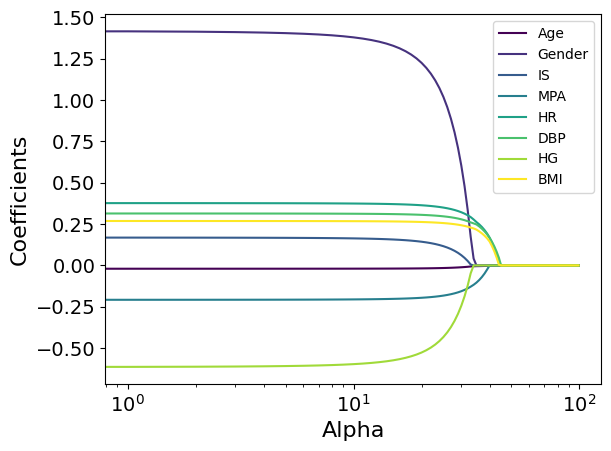

In [65]:
df = main_test[["Age", "Gender", "IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

### 9.1.1 Females only

<Figure size 1200x900 with 0 Axes>

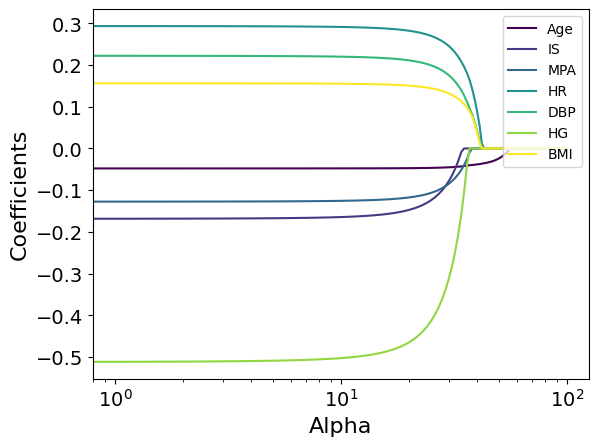

In [66]:
female = main_test[main_test["Gender"]==0]
df = female[["Age", "Gender", "IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

### 9.1.2 Males only

<Figure size 1200x900 with 0 Axes>

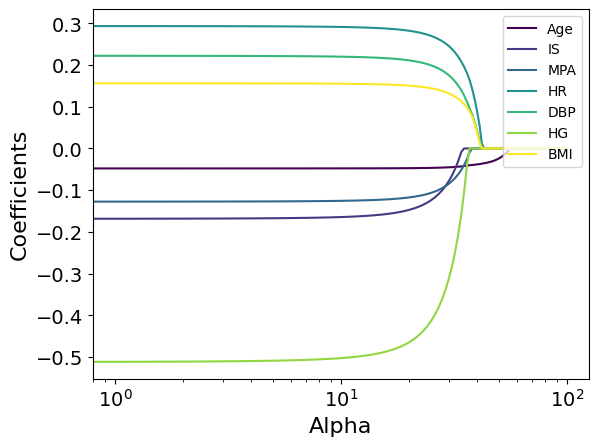

In [67]:
male = main_test[main_test["Gender"]==1]
df = female[["Age", "Gender", "IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

## 9.2 Self-report PA

<Figure size 1200x900 with 0 Axes>

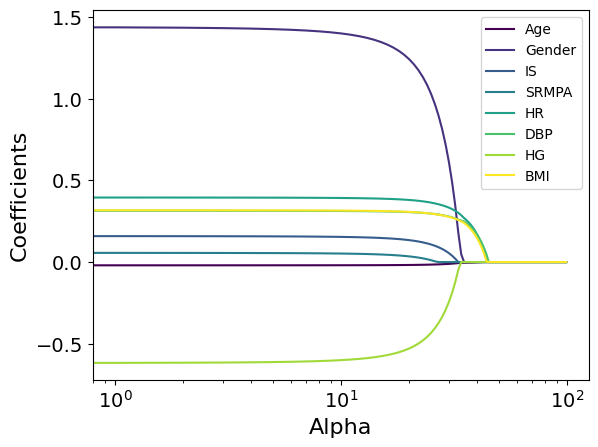

In [68]:
df = main_test[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

# 10 Figures for Paper

## 10.1 Scatterplot BrainAGE x Combined risk score

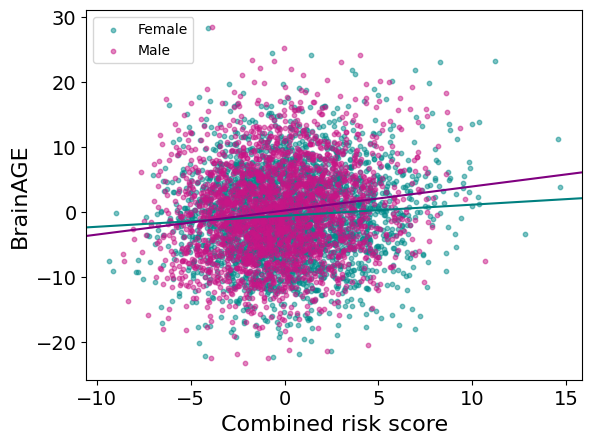

In [69]:
plt.figure()
plt.scatter("CR", "BA", data = female, label = "Female", alpha=0.5, s=10, color = "darkcyan")
plt.scatter("CR", "BA", data = male, label = "Male", alpha=0.5, s=10, color = "mediumvioletred")
plt.ylabel("BrainAGE", fontsize = 16)
plt.xlabel("Combined risk score", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.axline((0,-0.55), slope=0.17, color="teal")
plt.axline((0,0.25), slope=0.37, color="purple")
plt.show()

## 10.2 Smaller Correlation Heatmap

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'Gender'),
  Text(0, 2.5, 'MPA'),
  Text(0, 3.5, 'SRMPA'),
  Text(0, 4.5, 'HG'),
  Text(0, 5.5, 'HR'),
  Text(0, 6.5, 'BMI'),
  Text(0, 7.5, 'DBP'),
  Text(0, 8.5, 'SBP'),
  Text(0, 9.5, 'CR'),
  Text(0, 10.5, 'SRCR'),
  Text(0, 11.5, 'BA')])

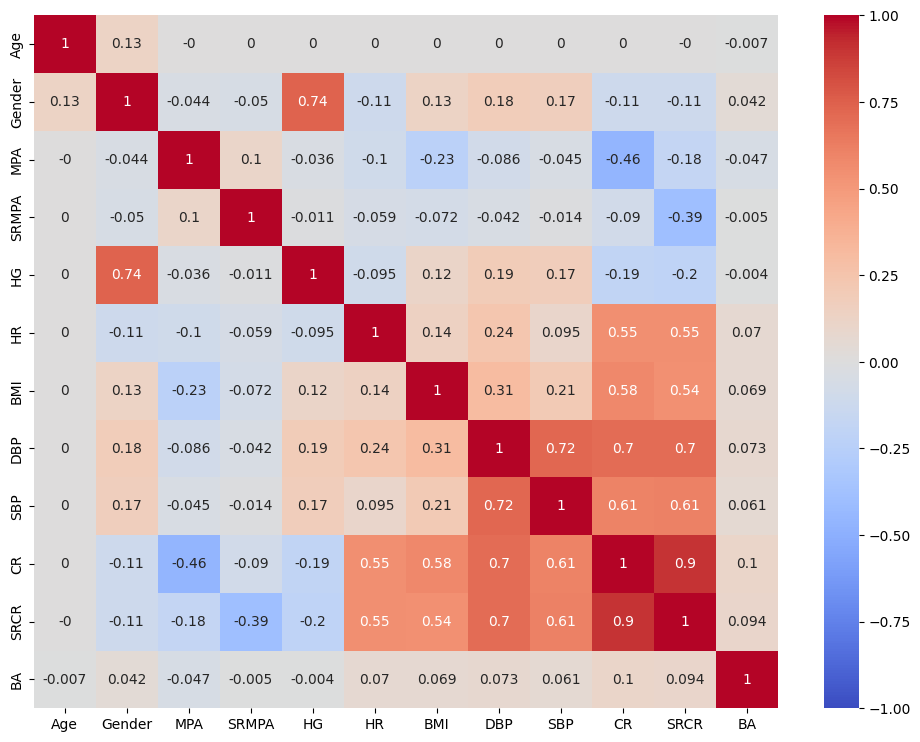

In [70]:
x = main_test
del x["IS"]
del x["LPA"]
del x["VPA"]
del x["SRLPA"]
del x["SRVPA"]

corr = x.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

### 10.2.1 Females only

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'MPA'),
  Text(0, 2.5, 'SRMPA'),
  Text(0, 3.5, 'HG'),
  Text(0, 4.5, 'HR'),
  Text(0, 5.5, 'BMI'),
  Text(0, 6.5, 'DBP'),
  Text(0, 7.5, 'SBP'),
  Text(0, 8.5, 'CR'),
  Text(0, 9.5, 'SRCR'),
  Text(0, 10.5, 'BA')])

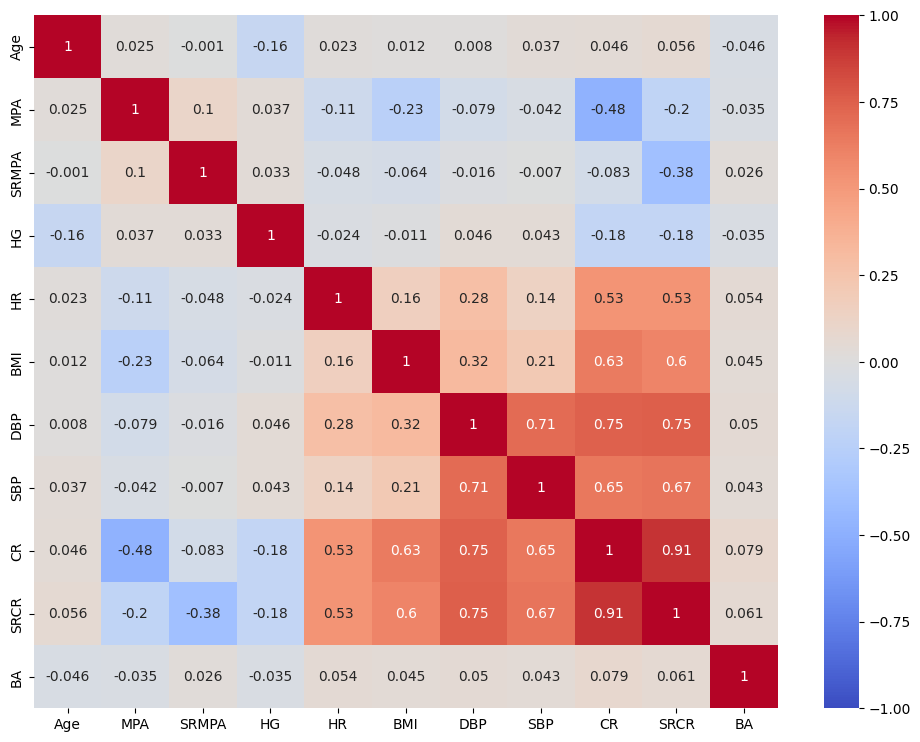

In [71]:
female = x[x["Gender"] == 0]
del female["Gender"]
corr = female.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

### 10.2.2 Males only

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'MPA'),
  Text(0, 2.5, 'SRMPA'),
  Text(0, 3.5, 'HG'),
  Text(0, 4.5, 'HR'),
  Text(0, 5.5, 'BMI'),
  Text(0, 6.5, 'DBP'),
  Text(0, 7.5, 'SBP'),
  Text(0, 8.5, 'CR'),
  Text(0, 9.5, 'SRCR'),
  Text(0, 10.5, 'BA')])

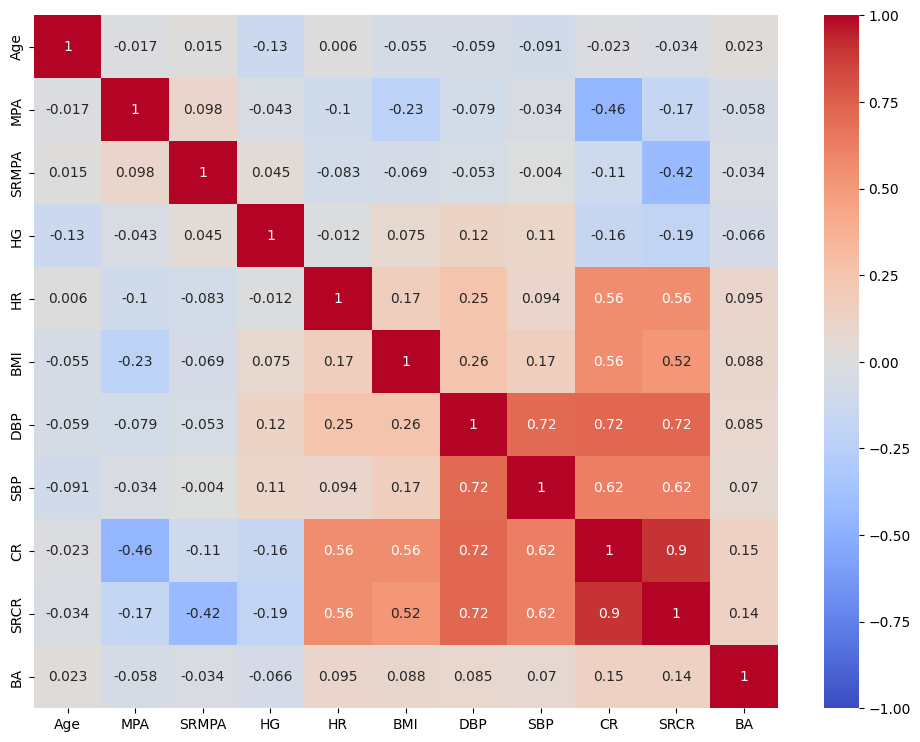

In [72]:
male = x[x["Gender"] == 1]
del male["Gender"]
corr = male.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

# 11 Exploration vs. Validation

## 11.1 Import processed Validation set

In [73]:
validate = pd.read_pickle("3_validate.pkl")
validate = pd.DataFrame(validate)

## 11.2 BrainAGE distribution

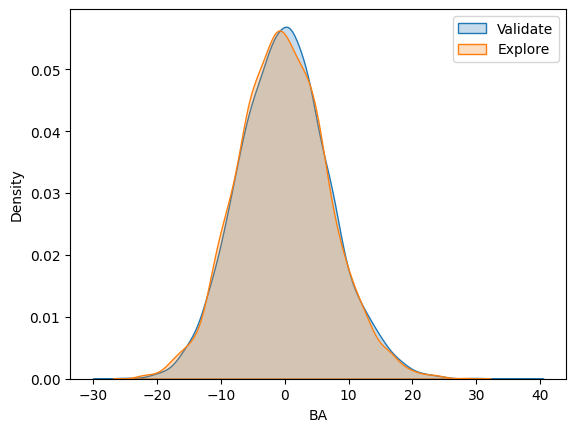

In [74]:
plt.figure()
sns.kdeplot(data = validate, x= 'BA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'BA', fill=True, label = "Explore")
plt.legend(loc="best")
plt.show()

## 11.3 MPA distribution

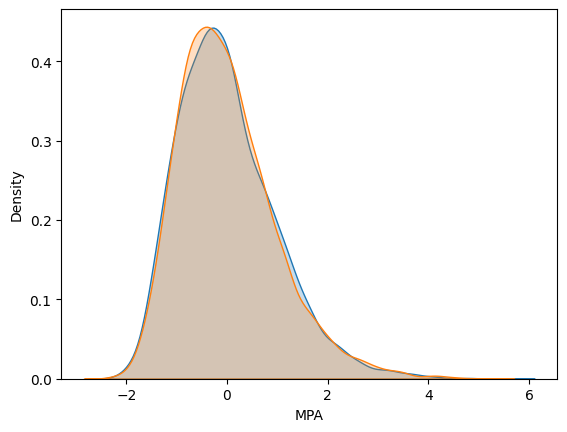

In [75]:
plt.figure()
sns.kdeplot(data = validate, x= 'MPA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Explore")
plt.show()